# Audio Evaluation — VibeShift Genre Transfer

Objective evaluation notebook comparing model outputs against targets and benchmark.

| Comparison pair | Purpose |
|---|---|
| `model_vs_target` | Primary quality signal |
| `benchmark_vs_target` | Baseline comparison |
| `model_vs_source` | Sanity check — how much did the model change audio? |

| Category | Metrics |
|---|---|
| Distributional | FAD (Fréchet Audio Distance) |
| Timbral | MFCC L2, MAE, Pearson r, frame L2, per-band MAE (13 coeffs) |
| Embedding | Cosine similarity (MFCC mean + std + Mel mean) |
| Spectral | Centroid, Rolloff, Bandwidth diff |
| Harmonic | Chroma cosine similarity + Pearson r |
| Reconstruction | Mel L1 / L2 |
| Bonus | RMS diff (dB), Tempo diff |
| Visualisation | PCA scatter with source→model / source→benchmark arrows + hover |

**Outputs** saved to `results/`: per-track CSV, summary CSV, FAD JSON, radar chart, bar chart, MFCC per-band line plot, PCA scatter.

In [1]:
# ── All imports ───────────────────────────────────────────────────────────────
import importlib, subprocess, sys

# Optional: frechet-audio-distance
FAD_LIB_AVAILABLE = False
try:
    import frechet_audio_distance  # noqa
    FAD_LIB_AVAILABLE = True
    print("frechet-audio-distance: available.")
except Exception as _fad_err:
    print(f"frechet-audio-distance unavailable ({_fad_err}). Numpy fallback will be used.")

# ── Standard imports ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import soundfile as sf  # noqa — keeps librosa backend happy
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import mplcursors

from scipy.linalg import sqrtm as _sqrtm
from scipy.spatial.distance import cosine as _cosine_dist
from scipy.stats import pearsonr

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("All imports ready.")
print(f"librosa {librosa.__version__} | numpy {np.__version__} | FAD lib: {FAD_LIB_AVAILABLE}")


c:\Users\Dhanuja\Desktop\Vibeshift\VibeShift\.venv\lib\site-packages\resampy\filters.py:50: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


frechet-audio-distance: available.
All imports ready.
librosa 0.11.0 | numpy 2.2.6 | FAD lib: True


## Configuration

Edit the paths in the cell below. All other cells read from these variables.

In [2]:
# ── Absolute folder paths — paste your own paths here ────────────────────────
from pathlib import Path

AUDIO_DIRS: dict[str, Path] = {
    "source"    : Path(r"C:\Users\Dhanuja\Downloads\dataset\Test\source"),
    "target"    : Path(r"C:\Users\Dhanuja\Downloads\dataset\Test\target"),
    "model"     : Path(r"C:\Users\Dhanuja\Desktop\CyberSecLecNotes\CYCLEGAN - Inferance-20260321T220837Z-1-001\CYCLEGAN - Inferance\inference_output"),
    "benchmark" : Path(r"C:\Users\Dhanuja\Desktop\CyberSecLecNotes\CYCLEGAN - Inferance-20260321T220837Z-1-001\CYCLEGAN - Inferance\reconstructed_audio_512"),
}

RESULTS_DIR = Path(r"C:\Users\Dhanuja\Downloads\Final Thesis\Diagrams\audio_evaluation")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Audio parameters ─────────────────────────────────────────────────────────
SR         = 44_100   # sample rate (mono)
N_MFCC     = 13       # MFCC coefficients
N_MELS     = 128      # mel filterbanks
HOP_LENGTH = 512
N_FFT      = 2048
N_CHROMA   = 12

AUDIO_EXTS = {".wav", ".mp3", ".flac", ".ogg", ".aif", ".aiff"}

# ── Comparison pairs ─────────────────────────────────────────────────────────
# (role_A, role_B, pair_label)
PAIRS = [
    ("model",     "target", "model_vs_target"),
    ("benchmark", "target", "benchmark_vs_target"),
    ("model",     "source", "model_vs_source"),
]

print(f"Results directory : {RESULTS_DIR}")
for role, path in AUDIO_DIRS.items():
    status = "OK" if path.exists() else "NOT FOUND"
    print(f"  [{status:9s}] {role:10s} → {path}")


Results directory : C:\Users\Dhanuja\Downloads\Final Thesis\Diagrams\audio_evaluation
  [OK       ] source     → C:\Users\Dhanuja\Downloads\dataset\Test\source
  [OK       ] target     → C:\Users\Dhanuja\Downloads\dataset\Test\target
  [OK       ] model      → C:\Users\Dhanuja\Desktop\CyberSecLecNotes\CYCLEGAN - Inferance-20260321T220837Z-1-001\CYCLEGAN - Inferance\inference_output
  [OK       ] benchmark  → C:\Users\Dhanuja\Desktop\CyberSecLecNotes\CYCLEGAN - Inferance-20260321T220837Z-1-001\CYCLEGAN - Inferance\reconstructed_audio_512


## File Discovery

Tracks are matched **by stem name** across all folders.  
If a folder shares zero stems with `target`, it falls back to **sorted-order pairing** and a warning is printed.  
Files that exist in `target` but not in another folder are skipped with a per-track warning.

In [3]:
def _audio_files(folder: Path) -> dict[str, Path]:
    """Return {stem: path} for all audio files in folder, sorted by stem."""
    if not folder.exists():
        return {}
    return {p.stem: p
            for p in sorted(folder.iterdir())
            if p.suffix.lower() in AUDIO_EXTS}


def discover_tracks() -> dict[str, dict[str, Path | None]]:
    """
    Build a track registry keyed by canonical track ID (the target stem).

    Matching strategy:
      1. Primary  — exact stem match across folders.
      2. Fallback — sorted positional pairing for any folder with zero stem
                    matches against target (warns, does not crash).

    Returns: {track_id: {role: Path | None}}
    """
    catalogs: dict[str, dict[str, Path]] = {
        role: _audio_files(d) for role, d in AUDIO_DIRS.items()
    }

    target_stems = list(catalogs.get("target", {}).keys())
    if not target_stems:
        raise FileNotFoundError(
            f"No audio files found in target folder: {AUDIO_DIRS['target']}\n"
            "Please update AUDIO_DIRS in the Configuration cell."
        )

    # Build registry by stem
    tracks: dict[str, dict[str, Path | None]] = {}
    for stem in target_stems:
        entry: dict[str, Path | None] = {}
        for role, cat in catalogs.items():
            entry[role] = cat.get(stem)  # None when no stem match
        tracks[stem] = entry

    # Sorted-order fallback for roles that share no stems with target
    for role, cat in catalogs.items():
        if role == "target" or not cat:
            continue
        matched = sum(1 for t in tracks.values() if t[role] is not None)
        if matched == 0:
            print(f"  [WARN] '{role}' — no stem matches found against target. "
                  f"Falling back to sorted positional pairing.")
            sorted_paths = list(cat.values())
            for i, stem in enumerate(target_stems):
                tracks[stem][role] = sorted_paths[i] if i < len(sorted_paths) else None

    # Per-track warnings
    for track_id, entry in tracks.items():
        missing = [r for r, p in entry.items() if p is None]
        if missing:
            print(f"  [WARN] '{track_id}' — missing in: {', '.join(missing)}")

    print(f"\nDiscovered {len(tracks)} tracks across {len(catalogs)} roles.")
    return tracks


TRACKS = discover_tracks()

  [WARN] 'source' — no stem matches found against target. Falling back to sorted positional pairing.
  [WARN] 'model' — no stem matches found against target. Falling back to sorted positional pairing.
  [WARN] 'benchmark' — no stem matches found against target. Falling back to sorted positional pairing.

Discovered 23 tracks across 4 roles.


## Feature Extraction

All audio is loaded at 44 100 Hz mono. Features are cached so each file is decoded only once.

In [4]:
def load_audio(path: Path) -> np.ndarray:
    """Load audio file as a float32 mono array at SR."""
    y, _ = librosa.load(str(path), sr=SR, mono=True)
    return y


def extract_features(y: np.ndarray) -> dict:
    """
    Extract all features required for evaluation.

    Returns a dict with:
      mfcc_matrix  [N_MFCC, T]   raw MFCC frames
      mfcc_mean    [N_MFCC]      per-coefficient mean
      mfcc_std     [N_MFCC]      per-coefficient std
      mel_db       [N_MELS, T]   log-mel frames
      mel_mean     [N_MELS]      per-band mean
      embedding    [N_MFCC*2 + N_MELS]  mfcc_mean ‖ mfcc_std ‖ mel_mean
      centroid, rolloff, bandwidth  (Hz scalars)
      chroma_mean  [N_CHROMA]
      rms          (linear scalar)
      tempo        (BPM scalar)
    """
    # MFCC
    mfcc_matrix = librosa.feature.mfcc(
        y=y, sr=SR, n_mfcc=N_MFCC,
        n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )  # [N_MFCC, T]
    mfcc_mean = mfcc_matrix.mean(axis=1)  # [N_MFCC]
    mfcc_std  = mfcc_matrix.std(axis=1)   # [N_MFCC]

    # Mel spectrogram (log scale)
    mel       = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )  # [N_MELS, T]
    mel_db    = librosa.power_to_db(mel, ref=np.max)  # [N_MELS, T]
    mel_mean  = mel_db.mean(axis=1)                   # [N_MELS]

    # Embedding: mfcc_mean || mfcc_std || mel_mean
    embedding = np.concatenate([mfcc_mean, mfcc_std, mel_mean])  # [2*N_MFCC + N_MELS]

    # Spectral shape features
    centroid  = float(librosa.feature.spectral_centroid(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH).mean())
    rolloff   = float(librosa.feature.spectral_rolloff(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH).mean())
    bandwidth = float(librosa.feature.spectral_bandwidth(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH).mean())

    # Chroma
    chroma      = librosa.feature.chroma_stft(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    chroma_mean = chroma.mean(axis=1)  # [N_CHROMA]

    # RMS energy (linear)
    rms   = float(librosa.feature.rms(y=y, hop_length=HOP_LENGTH).mean())

    # Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=SR)
    tempo = float(np.squeeze(tempo))

    return {
        "mfcc_matrix" : mfcc_matrix,
        "mfcc_mean"   : mfcc_mean,
        "mfcc_std"    : mfcc_std,
        "mel_db"      : mel_db,
        "mel_mean"    : mel_mean,
        "embedding"   : embedding,
        "centroid"    : centroid,
        "rolloff"     : rolloff,
        "bandwidth"   : bandwidth,
        "chroma_mean" : chroma_mean,
        "rms"         : rms,
        "tempo"       : tempo,
    }


# ── Feature cache ─────────────────────────────────────────────────────────────
_FEATURE_CACHE: dict[Path, dict] = {}

def get_features(path: Path | None) -> dict | None:
    """Load and cache features for a given path. Returns None on failure."""
    if path is None:
        return None
    if path not in _FEATURE_CACHE:
        try:
            y = load_audio(path)
            _FEATURE_CACHE[path] = extract_features(y)
        except Exception as exc:
            print(f"  [WARN] Could not load '{path.name}': {exc}")
            _FEATURE_CACHE[path] = None  # type: ignore[assignment]
    return _FEATURE_CACHE[path]


print("Feature extraction helpers defined.")

Feature extraction helpers defined.


## Pairwise Metrics

All metrics operate on a pair of feature dicts and return a flat dict of scalars.  
Time-varying features (MFCC matrix, Mel spectrogram) are trimmed to the shorter duration before comparison.

In [5]:
def _align(a: np.ndarray, b: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Trim two [F, T] arrays to the same time dimension."""
    t = min(a.shape[1], b.shape[1])
    return a[:, :t], b[:, :t]


def _safe_pearsonr(x: np.ndarray, y: np.ndarray) -> float:
    """Pearson r; returns 0.0 when either vector is constant."""
    if x.std() < 1e-8 or y.std() < 1e-8:
        return 0.0
    r, _ = pearsonr(x.astype(float), y.astype(float))
    return float(r)


def _safe_cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity in [-1, 1]; returns 0.0 when either vector is zero."""
    a, b = a.astype(np.float64), b.astype(np.float64)
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < 1e-10 or nb < 1e-10:
        return 0.0
    return float(np.dot(a, b) / (na * nb))


def compute_pairwise_metrics(feat_a: dict, feat_b: dict) -> dict:
    """Compute all pairwise metrics. Returns a flat {str: float} dict."""
    m: dict[str, float] = {}

    # ── MFCC: mean-level statistics ──────────────────────────────────────────
    mfcc_diff = feat_a["mfcc_mean"] - feat_b["mfcc_mean"]  # [N_MFCC]
    m["mfcc_l2"]       = float(np.linalg.norm(mfcc_diff))
    m["mfcc_mae"]      = float(np.mean(np.abs(mfcc_diff)))
    m["mfcc_pearsonr"] = _safe_pearsonr(feat_a["mfcc_mean"], feat_b["mfcc_mean"])

    # Per-coefficient MAE (coefficients 0–12 stored individually)
    for i, v in enumerate(np.abs(mfcc_diff)):
        m[f"mfcc_band_{i}_mae"] = float(v)

    # Frame-level L2 (time-aligned)
    mfcc_a, mfcc_b = _align(feat_a["mfcc_matrix"], feat_b["mfcc_matrix"])
    m["mfcc_frame_l2"] = float(np.sqrt(np.mean((mfcc_a - mfcc_b) ** 2)))

    # ── Embedding cosine similarity ──────────────────────────────────────────
    m["cosine_similarity"] = _safe_cosine_sim(feat_a["embedding"], feat_b["embedding"])

    # ── Spectral shape differences ───────────────────────────────────────────
    m["centroid_diff"]  = float(abs(feat_a["centroid"]  - feat_b["centroid"]))
    m["rolloff_diff"]   = float(abs(feat_a["rolloff"]   - feat_b["rolloff"]))
    m["bandwidth_diff"] = float(abs(feat_a["bandwidth"] - feat_b["bandwidth"]))

    # ── Chroma — cosine similarity AND Pearson r ─────────────────────────────
    m["chroma_cosine"]   = _safe_cosine_sim(feat_a["chroma_mean"], feat_b["chroma_mean"])
    m["chroma_pearsonr"] = _safe_pearsonr(feat_a["chroma_mean"], feat_b["chroma_mean"])

    # ── Mel spectrogram L1 / L2 ──────────────────────────────────────────────
    mel_a, mel_b = _align(feat_a["mel_db"], feat_b["mel_db"])
    mel_diff = mel_a - mel_b
    m["mel_l1"] = float(np.mean(np.abs(mel_diff)))
    m["mel_l2"] = float(np.sqrt(np.mean(mel_diff ** 2)))

    # ── RMS diff in dB ───────────────────────────────────────────────────────
    eps = 1e-9
    rms_db_a = 20.0 * np.log10(feat_a["rms"] + eps)
    rms_db_b = 20.0 * np.log10(feat_b["rms"] + eps)
    m["rms_db_diff"] = float(abs(rms_db_a - rms_db_b))

    # ── Tempo diff ───────────────────────────────────────────────────────────
    m["tempo_diff"] = float(abs(feat_a["tempo"] - feat_b["tempo"]))

    return m


print("Pairwise metrics function defined.")

Pairwise metrics function defined.


## Evaluation Loop — Extract Features and Compute All Pairwise Metrics

In [6]:
# ── Pre-cache features for every track × role ─────────────────────────────────
print("Extracting features (this may take a few minutes)...")
print("=" * 64)

_all_features: dict[str, dict[str, dict | None]] = {}
for track_id, entry in TRACKS.items():
    _all_features[track_id] = {}
    for role, path in entry.items():
        feat = get_features(path)
        _all_features[track_id][role] = feat
        status = "OK" if feat is not None else "FAIL"
        print(f"  [{status}] {track_id:40s} / {role}")

# ── Compute pairwise metrics ──────────────────────────────────────────────────
print("\n" + "=" * 64)
print("Computing pairwise metrics...")
print("=" * 64)

all_rows: list[dict] = []

for role_a, role_b, pair_label in PAIRS:
    dir_a = AUDIO_DIRS[role_a]
    dir_b = AUDIO_DIRS[role_b]

    if not dir_a.exists():
        print(f"  [SKIP] Pair '{pair_label}' — folder not found: {dir_a}")
        continue
    if not dir_b.exists():
        print(f"  [SKIP] Pair '{pair_label}' — folder not found: {dir_b}")
        continue

    n_ok = 0
    for track_id in TRACKS:
        feat_a = _all_features[track_id].get(role_a)
        feat_b = _all_features[track_id].get(role_b)

        if feat_a is None:
            print(f"  [SKIP] {track_id} — {role_a} unavailable")
            continue
        if feat_b is None:
            print(f"  [SKIP] {track_id} — {role_b} unavailable")
            continue

        row = compute_pairwise_metrics(feat_a, feat_b)
        row["track"]  = track_id
        row["pair"]   = pair_label
        row["role_a"] = role_a
        row["role_b"] = role_b
        all_rows.append(row)
        n_ok += 1

    print(f"  {pair_label}: {n_ok} tracks evaluated.")

print(f"\nTotal: {len(all_rows)} track-pair records.")

Extracting features (this may take a few minutes)...
  [OK] 02034_Vitamin_Pets_Is_Dead_instrumental_chunk005_10000ms / source
  [OK] 02034_Vitamin_Pets_Is_Dead_instrumental_chunk005_10000ms / target
  [OK] 02034_Vitamin_Pets_Is_Dead_instrumental_chunk005_10000ms / model
  [OK] 02034_Vitamin_Pets_Is_Dead_instrumental_chunk005_10000ms / benchmark
  [OK] 02034_Vitamin_Pets_Is_Dead_instrumental_chunk006_12000ms / source
  [OK] 02034_Vitamin_Pets_Is_Dead_instrumental_chunk006_12000ms / target
  [OK] 02034_Vitamin_Pets_Is_Dead_instrumental_chunk006_12000ms / model
  [OK] 02034_Vitamin_Pets_Is_Dead_instrumental_chunk006_12000ms / benchmark
  [OK] 02034_Vitamin_Pets_Is_Dead_instrumental_chunk007_14000ms / source
  [OK] 02034_Vitamin_Pets_Is_Dead_instrumental_chunk007_14000ms / target
  [OK] 02034_Vitamin_Pets_Is_Dead_instrumental_chunk007_14000ms / model
  [OK] 02034_Vitamin_Pets_Is_Dead_instrumental_chunk007_14000ms / benchmark
  [OK] 02034_Vitamin_Pets_Is_Dead_instrumental_chunk008_16000ms /

## FAD — Fréchet Audio Distance

FAD is a **folder-level** metric (distributional distance, not per-track).  
If `frechet-audio-distance` is available it is used directly; otherwise FAD is computed with the numpy Fréchet formula over the MFCC+Mel embedding statistics:

$$\text{FAD} = \|\mu_A - \mu_B\|^2 + \operatorname{Tr}\!\left(\Sigma_A + \Sigma_B - 2(\Sigma_A\Sigma_B)^{1/2}\right)$$

In [7]:
def _frechet_distance(mu1: np.ndarray, sigma1: np.ndarray,
                      mu2: np.ndarray, sigma2: np.ndarray) -> float:
    """Multivariate Fréchet distance (numpy implementation)."""
    diff = mu1 - mu2
    covmean = _sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        if not np.allclose(np.imag(covmean), 0, atol=1e-2):
            print("  [WARN] Large imaginary component in covmean sqrt — taking real part.")
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2.0 * covmean))


def _folder_fad_embeddings(folder: Path) -> np.ndarray:
    """
    Return an (N, N_MFCC) matrix of mfcc_mean vectors for FAD computation.

    Using only mfcc_mean (13 dims) instead of the full 154-dim embedding keeps
    the covariance matrix well-determined even with small track counts.
    """
    files = sorted(p for p in folder.iterdir() if p.suffix.lower() in AUDIO_EXTS)
    vecs = []
    for f in files:
        feat = get_features(f)
        if feat is not None:
            vecs.append(feat["mfcc_mean"])  # [N_MFCC] only
    if not vecs:
        raise ValueError(f"No valid embeddings extracted from {folder}")
    return np.stack(vecs)  # [N, N_MFCC]


def compute_fad_numpy(folder_a: Path, folder_b: Path) -> float:
    emb_a = _folder_fad_embeddings(folder_a)
    emb_b = _folder_fad_embeddings(folder_b)
    mu1, sigma1 = emb_a.mean(0), np.cov(emb_a, rowvar=False)
    mu2, sigma2 = emb_b.mean(0), np.cov(emb_b, rowvar=False)
    return _frechet_distance(mu1, sigma1, mu2, sigma2)


def compute_fad(folder_a: Path, folder_b: Path, label: str = "") -> float | None:
    """FAD dispatcher: try library first, fall back to numpy."""
    if FAD_LIB_AVAILABLE:
        try:
            from frechet_audio_distance import FrechetAudioDistance
            fad_obj = FrechetAudioDistance(use_pca=False, use_activation=False, verbose=False)
            score = float(fad_obj.score(str(folder_a), str(folder_b)))
            print(f"  FAD [{label}] = {score:.4f}  (library)")
            return score
        except Exception as exc:
            print(f"  Library FAD failed ({exc}). Falling back to numpy.")
    score = compute_fad_numpy(folder_a, folder_b)
    print(f"  FAD [{label}] = {score:.4f}  (numpy fallback)")
    return score


# ── Run FAD for each comparison pair ─────────────────────────────────────────
print("Computing FAD scores...")
fad_results: dict[str, float | None] = {}

for role_a, role_b, pair_label in PAIRS:
    dir_a = AUDIO_DIRS[role_a]
    dir_b = AUDIO_DIRS[role_b]
    if not dir_a.exists() or not dir_b.exists():
        print(f"  [SKIP] {pair_label} — one or both folders missing")
        fad_results[pair_label] = None
        continue
    try:
        fad_results[pair_label] = compute_fad(dir_a, dir_b, pair_label)
    except Exception as exc:
        print(f"  [ERROR] FAD for '{pair_label}': {exc}")
        fad_results[pair_label] = None

fad_path = RESULTS_DIR / "fad_scores.json"
with open(fad_path, "w") as _f:
    json.dump(fad_results, _f, indent=2)
print(f"\nSaved: {fad_path}")
print(json.dumps(fad_results, indent=2))


Computing FAD scores...


Using cache found in C:\Users\Dhanuja/.cache\torch\hub\harritaylor_torchvggish_master


  FAD [model_vs_target] = 15.3295  (library)


Using cache found in C:\Users\Dhanuja/.cache\torch\hub\harritaylor_torchvggish_master


  FAD [benchmark_vs_target] = 15.1457  (library)


Using cache found in C:\Users\Dhanuja/.cache\torch\hub\harritaylor_torchvggish_master


  FAD [model_vs_source] = 1.6138  (library)

Saved: C:\Users\Dhanuja\Downloads\Final Thesis\Diagrams\audio_evaluation\fad_scores.json
{
  "model_vs_target": 15.329527767497048,
  "benchmark_vs_target": 15.14566820034341,
  "model_vs_source": 1.6137795984193568
}


## Save Results — Per-Track CSV and Summary CSV

In [8]:
df_all = pd.DataFrame(all_rows)

# ── Column ordering ───────────────────────────────────────────────────────────
meta_cols = ["pair", "role_a", "role_b", "track"]
summary_metrics = [
    "mfcc_l2", "mfcc_mae", "mfcc_pearsonr", "mfcc_frame_l2",
    "cosine_similarity",
    "centroid_diff", "rolloff_diff", "bandwidth_diff",
    "chroma_cosine", "chroma_pearsonr",
    "mel_l1", "mel_l2",
    "rms_db_diff", "tempo_diff",
]
band_cols = [f"mfcc_band_{i}_mae" for i in range(N_MFCC)]
all_cols  = meta_cols + summary_metrics + band_cols
df_all = df_all[[c for c in all_cols if c in df_all.columns]]

# ── Per-track CSV ─────────────────────────────────────────────────────────────
per_track_path = RESULTS_DIR / "per_track_metrics.csv"
df_all.to_csv(per_track_path, index=False)
print(f"Saved: {per_track_path}  ({len(df_all)} rows)")

# ── Summary CSV: mean ± std per pair ─────────────────────────────────────────
grp = df_all.groupby("pair")[summary_metrics]
df_mean = grp.mean().add_suffix("_mean")
df_std  = grp.std().add_suffix("_std")
df_summary = pd.concat([df_mean, df_std], axis=1)

ordered_summary = []
for col in summary_metrics:
    ordered_summary += [f"{col}_mean", f"{col}_std"]
df_summary = df_summary[[c for c in ordered_summary if c in df_summary.columns]].reset_index()

summary_path = RESULTS_DIR / "summary_metrics.csv"
df_summary.to_csv(summary_path, index=False)
print(f"Saved: {summary_path}")

# Quick display (hide per-band columns for readability)
display_cols = ["pair"] + [f"{m}_mean" for m in summary_metrics
                            if f"{m}_mean" in df_summary.columns]
display(df_summary[display_cols].round(4))

Saved: C:\Users\Dhanuja\Downloads\Final Thesis\Diagrams\audio_evaluation\per_track_metrics.csv  (69 rows)
Saved: C:\Users\Dhanuja\Downloads\Final Thesis\Diagrams\audio_evaluation\summary_metrics.csv


,pair,mfcc_l2_mean,mfcc_mae_mean,mfcc_pearsonr_mean,mfcc_frame_l2_mean,cosine_similarity_mean,centroid_diff_mean,rolloff_diff_mean,bandwidth_diff_mean,chroma_cosine_mean,chroma_pearsonr_mean,mel_l1_mean,mel_l2_mean,rms_db_diff_mean,tempo_diff_mean
0,benchmark_vs_target,236.3712,48.5367,0.8333,72.7589,0.7681,2724.4535,3045.1405,507.4660,0.9696,-0.0697,27.4504,31.6432,2.9046,51.3531
1,model_vs_source,35.0711,6.2600,0.9997,15.1366,0.9991,841.2817,2172.0782,1179.2613,0.9853,0.7502,2.8284,5.4722,1.4605,24.9227
2,model_vs_target,638.2114,67.6969,0.8004,165.9269,0.8519,1238.8120,2523.7828,1157.2130,0.9900,0.2016,22.7323,26.6669,35.7277,37.3273


## Plot — Radar Chart (Similarity Metrics)

Higher values = more similar to target. Shows `model_vs_target` and `benchmark_vs_target`.

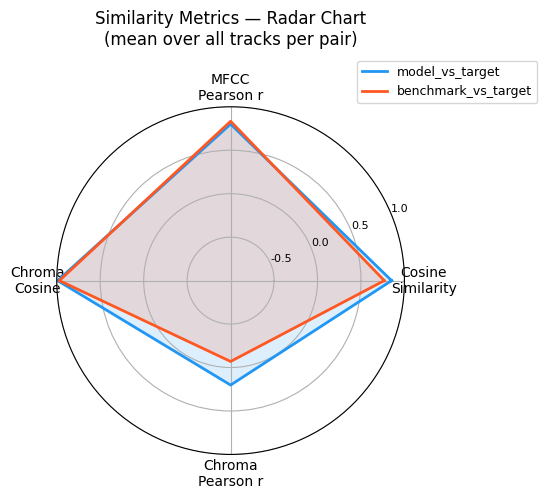

Saved: C:\Users\Dhanuja\Downloads\Final Thesis\Diagrams\audio_evaluation\radar_similarity.png


In [9]:
RADAR_METRICS = ["cosine_similarity", "mfcc_pearsonr", "chroma_cosine", "chroma_pearsonr"]
RADAR_LABELS  = ["Cosine\nSimilarity", "MFCC\nPearson r", "Chroma\nCosine", "Chroma\nPearson r"]

pair_means_radar = df_all.groupby("pair")[RADAR_METRICS].mean()
pairs_radar = [p for p in ["model_vs_target", "benchmark_vs_target"]
               if p in pair_means_radar.index]

if not pairs_radar:
    print("[SKIP] No data for radar chart.")
else:
    N = len(RADAR_METRICS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close polygon

    _colors_radar = {"model_vs_target": "#2196F3", "benchmark_vs_target": "#FF5722"}

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    for pair in pairs_radar:
        vals = pair_means_radar.loc[pair, RADAR_METRICS].tolist()
        vals += vals[:1]
        color = _colors_radar.get(pair, "gray")
        ax.plot(angles, vals, color=color, linewidth=2, label=pair)
        ax.fill(angles, vals, color=color, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, fontsize=10)
    ax.set_yticks([-0.5, 0.0, 0.5, 1.0])
    ax.set_yticklabels(["-0.5", "0.0", "0.5", "1.0"], fontsize=8)
    ax.set_ylim(-1.0, 1.0)
    ax.set_title("Similarity Metrics — Radar Chart\n(mean over all tracks per pair)",
                 fontsize=12, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=9)

    plt.tight_layout()
    radar_path = RESULTS_DIR / "radar_similarity.png"
    fig.savefig(radar_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {radar_path}")

## Plot — Bar Chart (Distance Metrics)

Lower values = closer to target. All three pairs shown for comparison.

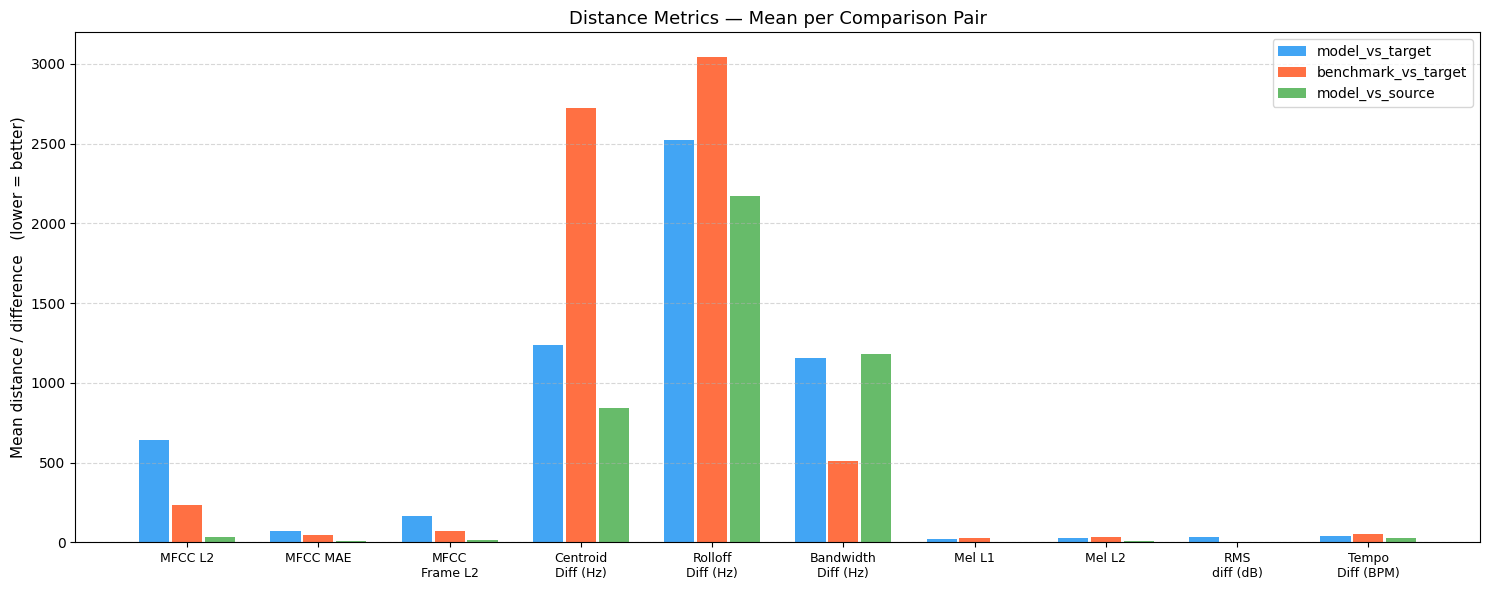

Saved: C:\Users\Dhanuja\Downloads\Final Thesis\Diagrams\audio_evaluation\bar_distance_metrics.png


In [10]:
BAR_METRICS = [
    "mfcc_l2", "mfcc_mae", "mfcc_frame_l2",
    "centroid_diff", "rolloff_diff", "bandwidth_diff",
    "mel_l1", "mel_l2",
    "rms_db_diff", "tempo_diff",
]
BAR_LABELS = [
    "MFCC L2", "MFCC MAE", "MFCC\nFrame L2",
    "Centroid\nDiff (Hz)", "Rolloff\nDiff (Hz)", "Bandwidth\nDiff (Hz)",
    "Mel L1", "Mel L2",
    "RMS\ndiff (dB)", "Tempo\nDiff (BPM)",
]

pair_means_bar = df_all.groupby("pair")[BAR_METRICS].mean()
pairs_bar = [p for p in ["model_vs_target", "benchmark_vs_target", "model_vs_source"]
             if p in pair_means_bar.index]

if not pairs_bar:
    print("[SKIP] No data for bar chart.")
else:
    x       = np.arange(len(BAR_METRICS))
    n_pairs = len(pairs_bar)
    width   = 0.75 / n_pairs
    _colors_bar = {
        "model_vs_target"     : "#2196F3",
        "benchmark_vs_target" : "#FF5722",
        "model_vs_source"     : "#4CAF50",
    }

    fig, ax = plt.subplots(figsize=(15, 6))
    for i, pair in enumerate(pairs_bar):
        vals   = pair_means_bar.loc[pair, BAR_METRICS].values
        offset = (i - n_pairs / 2 + 0.5) * width
        ax.bar(x + offset, vals, width=width * 0.92,
               color=_colors_bar.get(pair, "gray"), label=pair, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(BAR_LABELS, fontsize=9)
    ax.set_ylabel("Mean distance / difference   (lower = better)", fontsize=11)
    ax.set_title("Distance Metrics — Mean per Comparison Pair", fontsize=13)
    ax.legend(fontsize=10)
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    bar_path = RESULTS_DIR / "bar_distance_metrics.png"
    fig.savefig(bar_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {bar_path}")

## Plot — Per-Band MFCC MAE (Line Plot)

Shows the mean per-coefficient absolute error across the 13 MFCC bands, separately for model and benchmark against target.

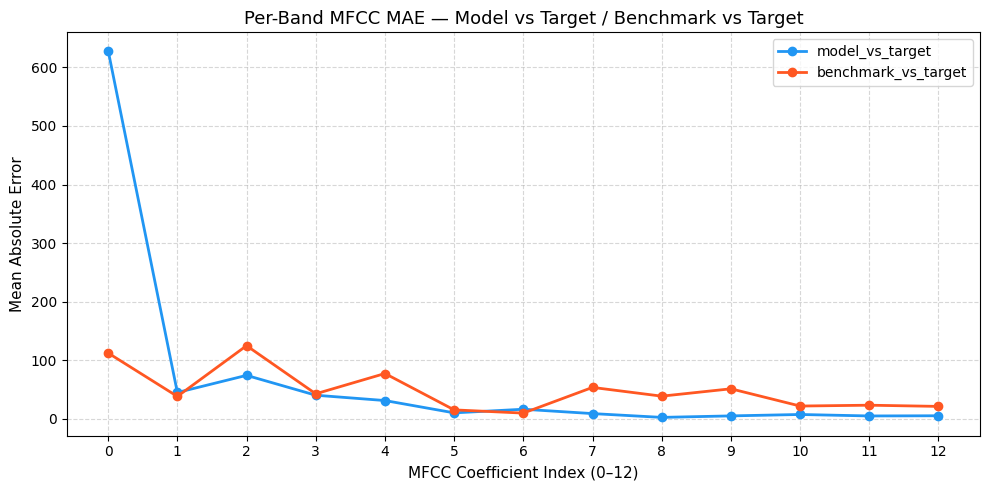

Saved: C:\Users\Dhanuja\Downloads\Final Thesis\Diagrams\audio_evaluation\mfcc_per_band_mae.png


In [11]:
band_cols_present = [f"mfcc_band_{i}_mae" for i in range(N_MFCC)
                     if f"mfcc_band_{i}_mae" in df_all.columns]
pair_band_means = df_all.groupby("pair")[band_cols_present].mean()

pairs_band = [p for p in ["model_vs_target", "benchmark_vs_target"]
              if p in pair_band_means.index]

if not pairs_band:
    print("[SKIP] No data for per-band MFCC plot.")
else:
    band_indices = list(range(len(band_cols_present)))
    _colors_band = {"model_vs_target": "#2196F3", "benchmark_vs_target": "#FF5722"}

    fig, ax = plt.subplots(figsize=(10, 5))
    for pair in pairs_band:
        vals = pair_band_means.loc[pair, band_cols_present].values
        ax.plot(band_indices, vals, marker="o", linewidth=2,
                color=_colors_band.get(pair, "gray"), label=pair)

    ax.set_xlabel("MFCC Coefficient Index (0–12)", fontsize=11)
    ax.set_ylabel("Mean Absolute Error", fontsize=11)
    ax.set_title("Per-Band MFCC MAE — Model vs Target / Benchmark vs Target", fontsize=13)
    ax.set_xticks(band_indices)
    ax.set_xticklabels([str(i) for i in band_indices])
    ax.legend(fontsize=10)
    ax.grid(linestyle="--", alpha=0.5)

    plt.tight_layout()
    band_path = RESULTS_DIR / "mfcc_per_band_mae.png"
    fig.savefig(band_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {band_path}")

## Plot — PCA Scatter with Source→Model / Source→Benchmark Arrows

**How it works:**
- The MFCC mean vector `[N_MFCC]` is extracted for every track in every group.
- All four groups are **stacked into one matrix** and a single PCA is fit (shared coordinate space).
- Each group is projected into the same 2D plane and plotted with its own colour.
- Blue arrows connect `source → model` per track; orange arrows connect `source → benchmark` per track.
- **Hover** over any point to see the track name and its MFCC L2 distance-to-target for both model and benchmark.

> **Note:** Run this cell with `%matplotlib widget` (ipympl) for interactive hover. Falls back to static if ipympl is absent.

In [12]:
# ── Try interactive backend; fall back to Agg ─────────────────────────────────
try:
    import ipympl
    get_ipython().run_line_magic('matplotlib', 'widget')
    _interactive = True
except Exception:
    _interactive = False
    print("Running in static mode — PCA saved as PNG.")

# ── Collect MFCC mean vectors from the feature cache ─────────────────────────
_groups = list(AUDIO_DIRS.keys())          # [source, target, model, benchmark]
_track_order = list(TRACKS.keys())         # canonical order

# group_vecs[group] = list of (track_id, mfcc_mean_vector)
group_vecs: dict[str, list[tuple[str, np.ndarray]]] = {g: [] for g in _groups}
for tid in _track_order:
    for g in _groups:
        feat = _all_features.get(tid, {}).get(g)
        if feat is not None:
            group_vecs[g].append((tid, feat["mfcc_mean"]))

# ── Stack all vectors, fit ONE PCA on the combined matrix ─────────────────────
all_vecs: list[np.ndarray] = []
group_labels_flat: list[str] = []
for g in _groups:
    for _, v in group_vecs[g]:
        all_vecs.append(v)
        group_labels_flat.append(g)

if len(all_vecs) < 4:
    print("[SKIP] Not enough feature vectors for PCA — check audio folders.")
else:
    X = np.stack(all_vecs)  # [N_total, N_MFCC]
    scaler  = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_scaled)  # [N_total, 2]

    var1 = pca.explained_variance_ratio_[0] * 100
    var2 = pca.explained_variance_ratio_[1] * 100
    var_total = var1 + var2
    print(f"PCA variance explained: {var_total:.1f}%  (PC1={var1:.1f}%, PC2={var2:.1f}%)")

    # ── Split 2D coords back into groups ────────────────────────────────────
    # coords_by_group[group] = {track_id: np.array([x, y])}
    coords_by_group: dict[str, dict[str, np.ndarray]] = {g: {} for g in _groups}
    idx = 0
    for g in _groups:
        for tid, _ in group_vecs[g]:
            coords_by_group[g][tid] = X_2d[idx]
            idx += 1

    # ── Pre-build MFCC L2 distance-to-target lookup for hover labels ─────────
    _dist_to_target: dict[str, dict[str, float]] = {
        "model_vs_target"     : {},
        "benchmark_vs_target" : {},
    }
    for row in all_rows:
        if row["pair"] in _dist_to_target:
            _dist_to_target[row["pair"]][row["track"]] = row["mfcc_l2"]

    # ── Visual settings ───────────────────────────────────────────────────────
    _pca_colors = {
        "source"    : "#8B5CF6",
        "target"    : "#10B981",
        "model"     : "#3B82F6",
        "benchmark" : "#F97316",
    }

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#e0e0e0")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlabel(f"PC1  ({var1:.1f}% variance explained)", fontsize=11)
    ax.set_ylabel(f"PC2  ({var2:.1f}% variance explained)", fontsize=11)
    ax.set_title("MFCC space — PCA projection", fontsize=12, fontweight="normal", pad=12)
    ax.grid(True, linestyle="--", alpha=0.15, color="gray")

    # ── Scatter points ────────────────────────────────────────────────────────
    scatter_artists: dict[str, object] = {}
    scatter_track_ids: dict[str, list[str]] = {}

    for g in _groups:
        if not coords_by_group[g]:
            continue
        tids = list(coords_by_group[g].keys())
        xy   = np.stack([coords_by_group[g][tid] for tid in tids])
        sc = ax.scatter(
            xy[:, 0], xy[:, 1],
            c=_pca_colors[g], marker="o",
            s=90, alpha=0.85,
            edgecolors="white", linewidths=0.6,
            label=g, zorder=3,
        )
        scatter_artists[g] = sc
        scatter_track_ids[g] = tids

    # ── Legend ─────────────────────────────────────────────────────────────────
    ax.legend(fontsize=10, loc="lower right", frameon=False)

    # ── Hover tooltips ────────────────────────────────────────────────────────
    if _interactive:
        try:
            _active_artists = list(scatter_artists.values())
            _active_groups  = list(scatter_artists.keys())
            cursor = mplcursors.cursor(_active_artists, hover=True)

            @cursor.connect("add")
            def _on_hover(sel):
                g_idx = _active_artists.index(sel.artist)
                g     = _active_groups[g_idx]
                tids  = scatter_track_ids[g]
                i     = sel.index
                if i >= len(tids):
                    return
                tid = tids[i]
                tip = f"Track : {tid}\nGroup : {g}"
                mdl_d  = _dist_to_target["model_vs_target"].get(tid)
                bnch_d = _dist_to_target["benchmark_vs_target"].get(tid)
                if mdl_d  is not None:
                    tip += f"\nmodel→target  MFCC L2 : {mdl_d:.3f}"
                if bnch_d is not None:
                    tip += f"\nbench→target  MFCC L2 : {bnch_d:.3f}"
                sel.annotation.set_text(tip)
                sel.annotation.get_bbox_patch().set(
                    boxstyle="round,pad=0.4",
                    facecolor="white",
                    edgecolor="#e0e0e0",
                )
                sel.annotation.set_fontsize(9)
        except Exception as _cur_err:
            print(f"  [WARN] Hover tooltip setup failed: {_cur_err}")
    else:
        print("  (Hover disabled — static plot)")

    plt.tight_layout()
    pca_path = RESULTS_DIR / "pca_scatter.png"
    fig.savefig(pca_path, dpi=150, bbox_inches="tight")
    if _interactive:
        plt.show()
    else:
        plt.close(fig)
    print(f"Saved: {pca_path}")


Running in static mode — PCA saved as PNG.
PCA variance explained: 74.8%  (PC1=53.8%, PC2=21.0%)
  (Hover disabled — static plot)
Saved: C:\Users\Dhanuja\Downloads\Final Thesis\Diagrams\audio_evaluation\pca_scatter.png


## Final Summary

All outputs written to `results/`:

| File | Contents |
|---|---|
| `per_track_metrics.csv` | Every metric for every (track, pair) combination |
| `summary_metrics.csv` | Mean ± std of each metric grouped by pair |
| `fad_scores.json` | FAD score per comparison pair |
| `radar_similarity.png` | Radar chart of similarity metrics |
| `bar_distance_metrics.png` | Bar chart of distance metrics |
| `mfcc_per_band_mae.png` | Per-coefficient MFCC MAE line plot |
| `pca_scatter.png` | PCA 2D scatter with arrows and hover |

In [13]:
print("Results directory contents:")
for f in sorted(RESULTS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:35s}  {size_kb:6.1f} KB")

Results directory contents:
  bar_distance_metrics.png               64.1 KB
  fad_scores.json                         0.1 KB
  mfcc_per_band_mae.png                  81.0 KB
  pca_scatter.png                        85.4 KB
  per_track_metrics.csv                  39.8 KB
  radar_similarity.png                  101.6 KB
  summary_metrics.csv                     2.1 KB
